<a href="https://colab.research.google.com/github/DeepthiManthapuram/Deep_Learning/blob/main/Convolutional_autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import(
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)
from tensorflow.keras.models import Model

In [2]:
#Load MNIST Dataset
(x_train, _), (x_test, _) = mnist.load_data()

print("Training Images :", x_train.shape)
print("Testing Images  :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)


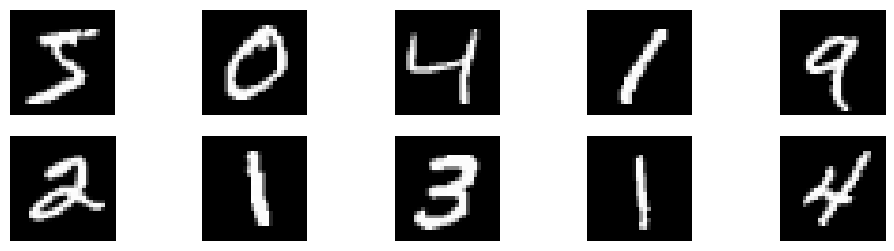

In [3]:
plt.figure(figsize=(12,3))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis("off")

plt.show()

In [4]:
#Preprocess the Images
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

x_train = np.reshape(x_train, (len(x_train),28,28,1))
x_test = np.reshape(x_test, (len(x_test),28,28,1))

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [5]:
#Build the Encoder
input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same', name="Latent_Space")(x)

In [6]:
#Build the Decoder
# Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

In [7]:
#Create the Convolutional Autoencoder
autoencoder = Model(input_img, decoded)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Space (MaxPooling2D)     │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#Compile the Model
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [ ]:
#Train the Model
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 119s 246ms/step - loss: 0.1263 - val_loss: 0.0809
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 240ms/step - loss: 0.0783 - val_loss: 0.0751
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 112s 239ms/step - loss: 0.0746 - val_loss: 0.0728
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 237ms/step - loss: 0.0727 - val_loss: 0.0714
Epoch 5/10
267/469 ━━━━━━━━━━━━━━━━━━━━ 45s 227ms/step - loss: 0.0719

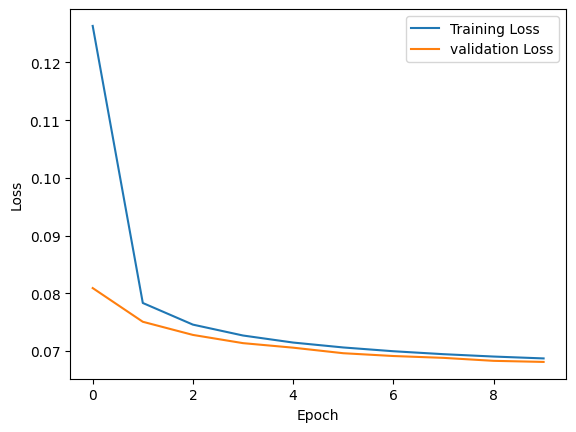

In [10]:
#Plot Training Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [11]:
#Predict Reconstructed Images
decoded_imgs = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


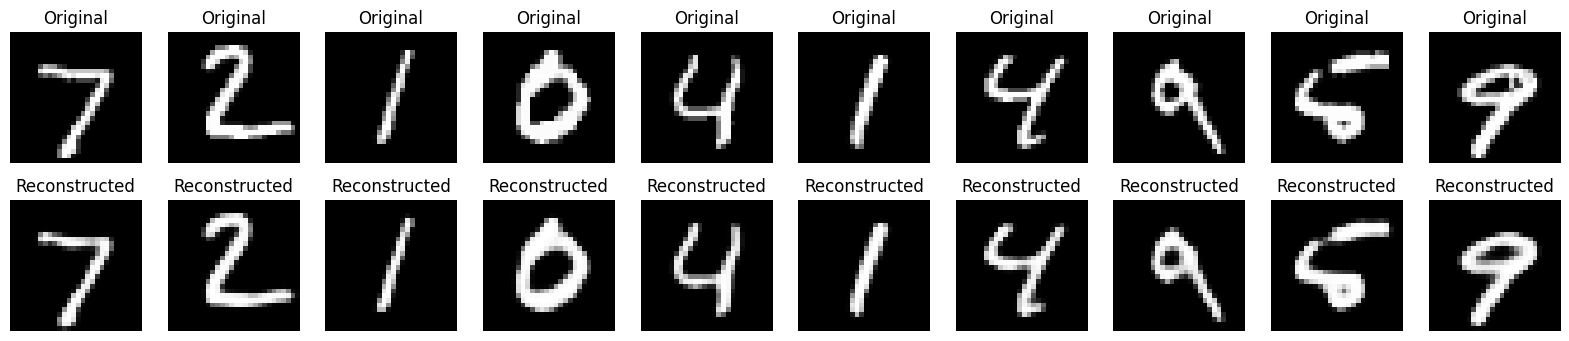

In [12]:
#Display Original vs Reconstructed Images
n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

In [14]:
#Create Encoder Model
encoder = Model(inputs=input_img, outputs=encoded)

encoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Space (MaxPooling2D)     │ (None, 7, 7, 16)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,944 (19.31 KB)

 Trainable params: 4,944 (19.31 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#Extract Latent Features
latent_features = encoder.predict(x_test)

print("Latent Feature Shape :", latent_features.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Latent Feature Shape : (10000, 7, 7, 16)


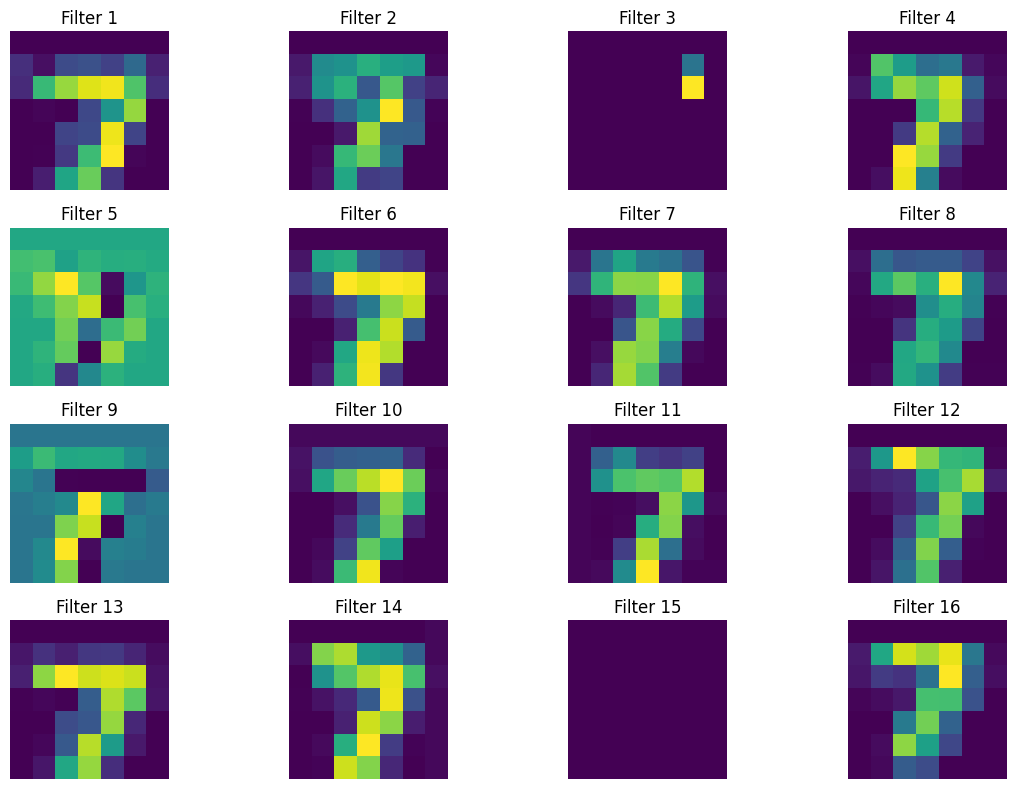

In [16]:
#Visualize Latent Feature Maps
plt.figure(figsize=(12,8))

for i in range(16):

    plt.subplot(4,4,i+1)
    plt.imshow(latent_features[0,:,:,i], cmap='viridis')
    plt.axis("off")
    plt.title(f"Filter {i+1}")

plt.tight_layout()
plt.show()

In [17]:
#Compare Compression
print("Original Image Shape :", x_test[0].shape)
print("Compressed Shape     :", latent_features[0].shape)

Original Image Shape : (28, 28, 1)
Compressed Shape     : (7, 7, 16)


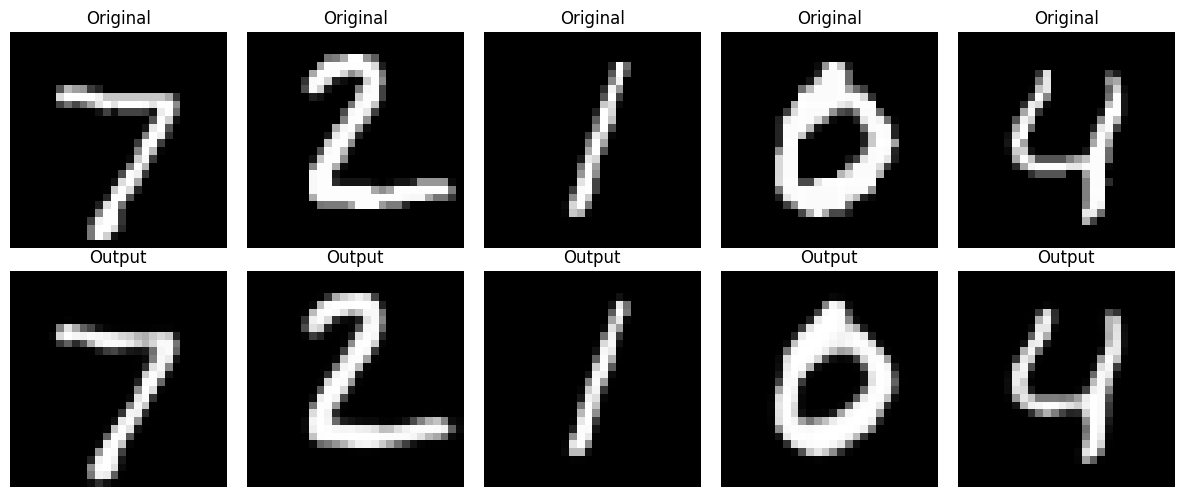

In [18]:
#Visualize Multiple Reconstructions
num_images = 5

plt.figure(figsize=(12,5))

for i in range(num_images):

    # Original
    plt.subplot(2,num_images,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2,num_images,i+1+num_images)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Output")
    plt.axis('off')

plt.tight_layout()
plt.show()